# Lesson 10: Distributed sources

Neurocampus course "Signals of the whole brain"

Daria Kleeva

dkleeva@gmail.com

May 20th, 2026


In [ ]:
#!pip3 install mne-connectivity

In [1]:
import matplotlib.pyplot as plt
import mne
from mne.datasets import sample, fetch_fsaverage
from mne.beamformer import make_lcmv, apply_lcmv
import numpy as np
import os.path as op
from mne.minimum_norm import make_inverse_operator, apply_inverse
from mne_connectivity.viz import plot_connectivity_circle
from mne.viz import circular_layout

## Data import

Opening raw data file /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
72 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
3 projection items activated
Loading data for 72 events and 106 original time points ...
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on MAG : ['MEG 1711']
  

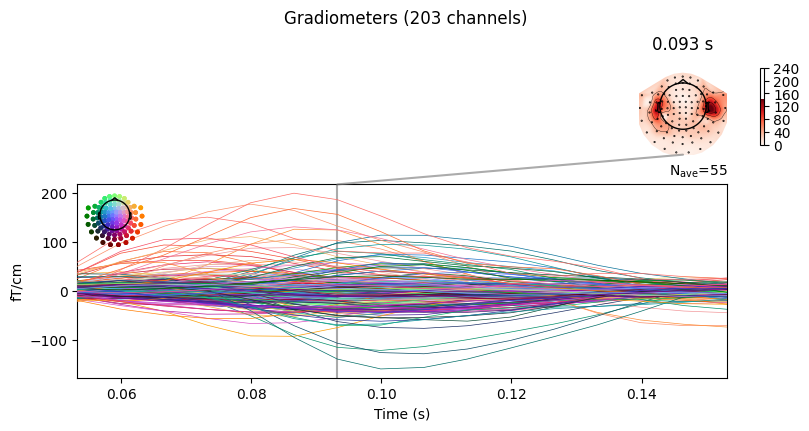

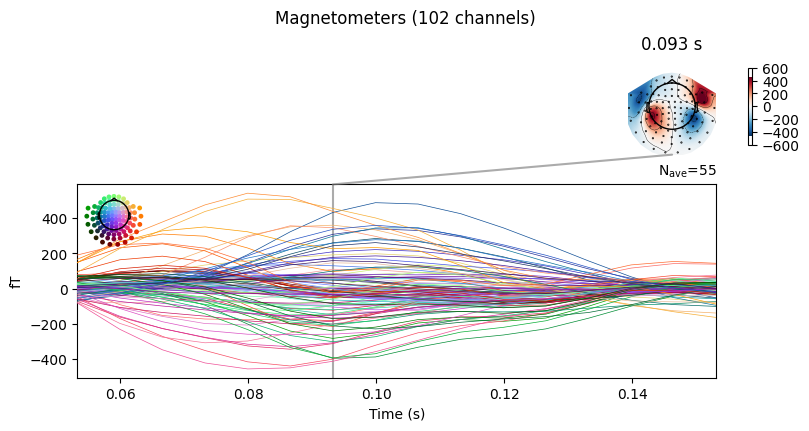

[<Figure size 800x420 with 4 Axes>, <Figure size 800x420 with 4 Axes>]

In [2]:
data_path = sample.data_path()
subjects_dir = str(data_path) + '/subjects'
raw_fname = str(data_path) + '/MEG/sample/sample_audvis_filt-0-40_raw.fif'

raw = mne.io.read_raw_fif(raw_fname)
raw.info['bads'] = ['MEG 2443']  
event_id = 1  
tmin, tmax = -0.2, 0.5
events = mne.find_events(raw)
raw.pick(['meg', 'eog']) 
epochs = mne.Epochs(raw, events, event_id, tmin, tmax,
                    baseline=(None, 0), preload=True,
                    reject=dict(grad=4000e-13, mag=4e-12, eog=150e-6))
evoked = epochs.average().crop(0.05, 0.15)
evoked.plot_joint()

## Forward model

In [3]:
fwd_fname = str(data_path) + '/MEG/sample/sample_audvis-meg-vol-7-fwd.fif'
forward = mne.read_forward_solution(fwd_fname)

Reading forward solution from /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis-meg-vol-7-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (3757 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


## Covariance matrix

    Created an SSP operator (subspace dimension = 3)
    Setting small MEG eigenvalues to zero (without PCA)
Reducing data rank from 305 -> 302
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 2035
[done]
    Created an SSP operator (subspace dimension = 3)
    Setting small MEG eigenvalues to zero (without PCA)
Reducing data rank from 305 -> 302
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 1705
[done]
Computing rank from covariance with rank=None
    Using tolerance 4e-14 (2.2e-16 eps * 102 dim * 1.8  max singular value)
    Estimated rank (mag): 99
    MAG: rank 99 computed from 102 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 4.3e-13 (2.2e-16 eps * 203 dim * 9.4  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors


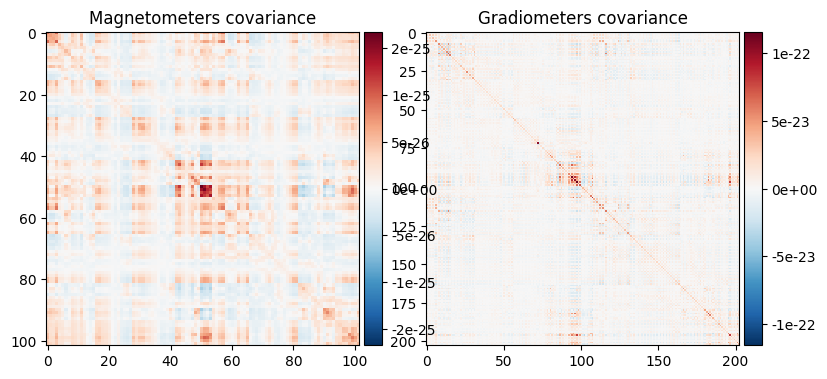

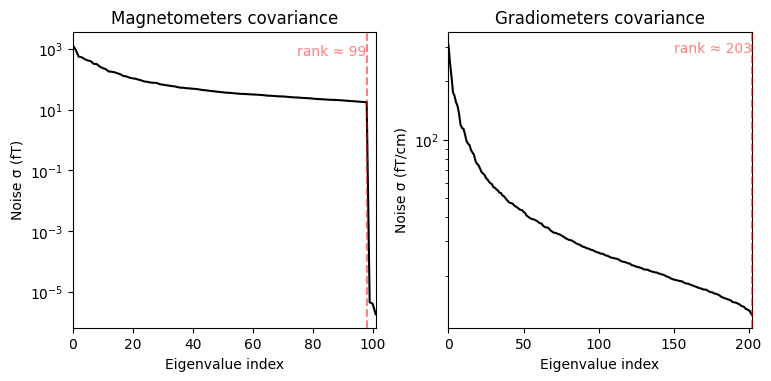

Computing rank from covariance with rank=None
    Using tolerance 2.3e-14 (2.2e-16 eps * 102 dim * 1  max singular value)
    Estimated rank (mag): 99
    MAG: rank 99 computed from 102 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 1.6e-13 (2.2e-16 eps * 203 dim * 3.5  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors


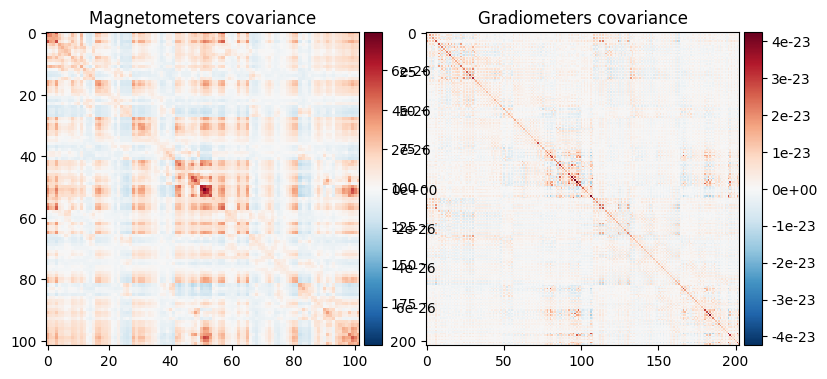

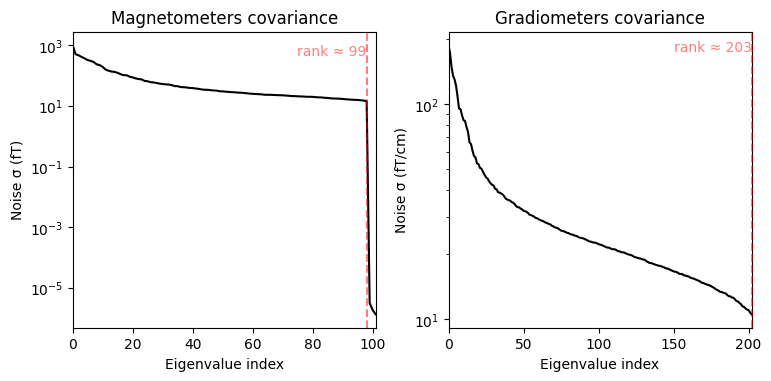

(<Figure size 760x370 with 4 Axes>, <Figure size 760x370 with 2 Axes>)

In [4]:
data_cov = mne.compute_covariance(epochs, tmin=0.01, tmax=0.25,
                                  method='empirical')
noise_cov = mne.compute_covariance(epochs, tmin=tmin, tmax=0,
                                   method='empirical')
data_cov.plot(epochs.info)
noise_cov.plot(epochs.info)

Projections have already been applied. Setting proj attribute to True.


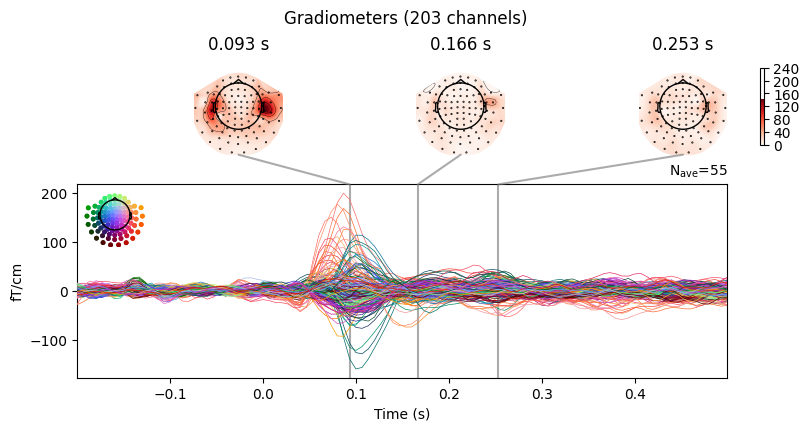

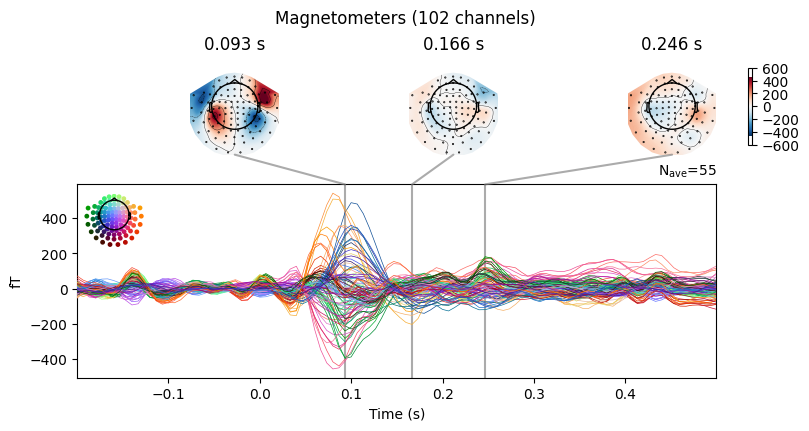

In [5]:
fig = epochs.average().plot_joint()

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Computing rank from covariance with rank=None
    Using tolerance 1.6e-13 (2.2e-16 eps * 203 dim * 3.5  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 2.3e-14 (2.2e-16 eps * 102 dim * 1  max singular value)
    Estimated rank (mag): 99
    MAG: rank 99 computed from 102 data channels with 3 projectors
    Created an SSP operator (subspace dimension = 3)
Computing rank from covariance with rank={'grad': 203, 'mag': 99, 'meg': 302}
    Setting small MEG eigenvalues to zero (without PCA)
    Created the whitener using a noise covariance matrix with rank 302 (3 small eigenvalues omitted)


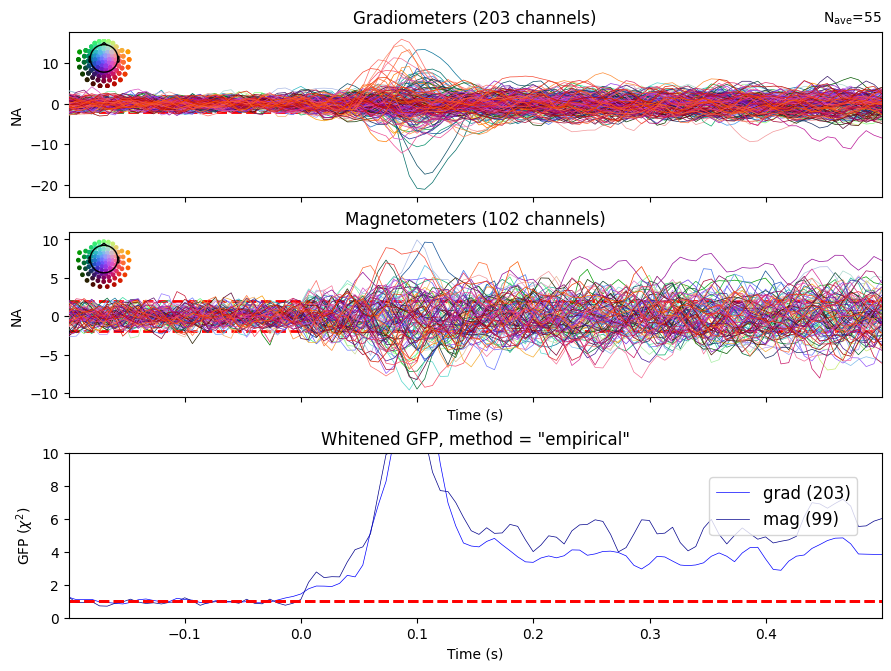

In [6]:
fig = epochs.average().plot_white(noise_cov)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Computing rank from covariance with rank=None
    Using tolerance 4.3e-13 (2.2e-16 eps * 203 dim * 9.4  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 4e-14 (2.2e-16 eps * 102 dim * 1.8  max singular value)
    Estimated rank (mag): 99
    MAG: rank 99 computed from 102 data channels with 3 projectors
    Created an SSP operator (subspace dimension = 3)
Computing rank from covariance with rank={'grad': 203, 'mag': 99, 'meg': 302}
    Setting small MEG eigenvalues to zero (without PCA)
    Created the whitener using a noise covariance matrix with rank 302 (3 small eigenvalues omitted)


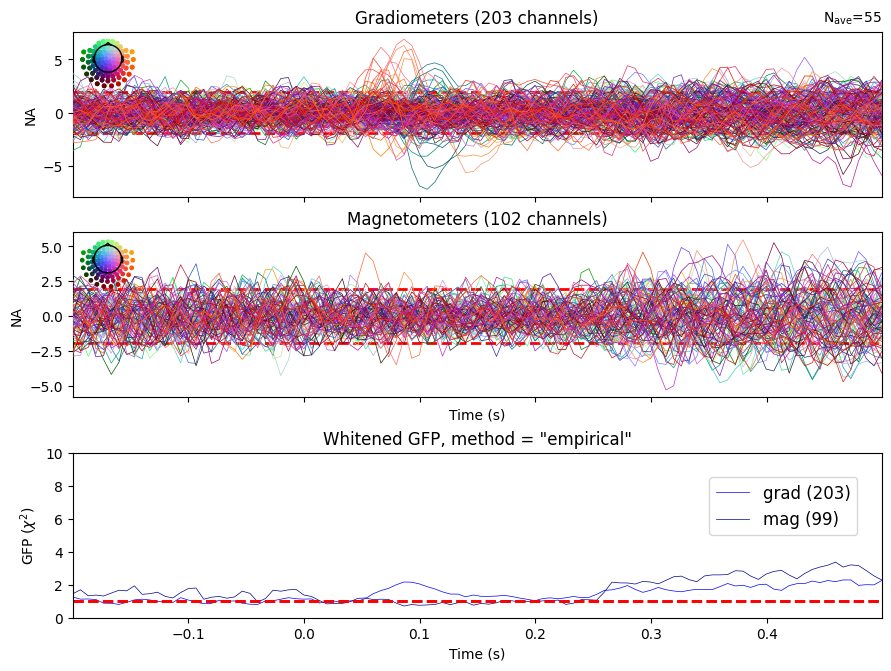

In [7]:
fig = epochs.average().plot_white(data_cov)

## Spatial filter

In [8]:
#Scalar
filters = make_lcmv(evoked.info, forward, data_cov, reg=0.05,
                    noise_cov=noise_cov, pick_ori='max-power',
                    weight_norm='unit-noise-gain', rank=None)
#Vector
filters_vec = make_lcmv(evoked.info, forward, data_cov, reg=0.05,
                        noise_cov=noise_cov, pick_ori='vector',
                        weight_norm='unit-noise-gain', rank=None)
src = forward['src']

Computing rank from covariance with rank=None
    Using tolerance 7.1e-13 (2.2e-16 eps * 305 dim * 10  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
Computing rank from covariance with rank=None
    Using tolerance 2.9e-13 (2.2e-16 eps * 305 dim * 4.3  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
Making LCMV beamformer with rank {'meg': 302}
Computing inverse operator with 305 channels.
    305 out of 306 channels remain after picking
Selected 305 channels
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 3)
Computing rank from covariance with rank={'meg': 302}
    Setting small MEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 3757 sources


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/beamformer/_compute_beamformer.py:243: RuntimeWarning: divide by zero encountered in matmul
  Cm = whitener @ Cm @ whitener.T.conj()
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/beamformer/_compute_beamformer.py:243: RuntimeWarning: overflow encountered in matmul
  Cm = whitener @ Cm @ whitener.T.conj()
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/beamformer/_compute_beamformer.py:243: RuntimeWarning: invalid value encountered in matmul
  Cm = whitener @ Cm @ whitener.T.conj()
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/utils/numerics.py:191: RuntimeWarning: divide by zero encountered in matmul
  x_inv = np.matmul(U * s_inv[..., np.newaxis, :], Vh)
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/utils/numerics.py:191: RuntimeWarning: overflow encountered in matmul
  x_inv = np.matmul(U * s_inv[..., np.newaxis, :], Vh)
/Users/dkleeva/Library/Python/3.9/lib

Filter computation complete
Computing rank from covariance with rank=None
    Using tolerance 7.1e-13 (2.2e-16 eps * 305 dim * 10  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
Computing rank from covariance with rank=None
    Using tolerance 2.9e-13 (2.2e-16 eps * 305 dim * 4.3  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
Making LCMV beamformer with rank {'meg': 302}
Computing inverse operator with 305 channels.
    305 out of 306 channels remain after picking
Selected 305 channels
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 3)
Computing rank from covariance with rank={'meg': 302}
    Setting small MEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 3757 sources
Filter computation complete


In [9]:
stc = apply_lcmv(evoked, filters)
stc_vec = apply_lcmv(evoked, filters_vec)

## Results of beamforming

In [10]:
lims = [0.3, 0.45, 0.6]
kwargs = dict(src=src, subject='sample', subjects_dir=subjects_dir,
              initial_time=0.087, verbose=True)

In [11]:
stc

<VolSourceEstimate | 3757 vertices, subject : sample, tmin : 53.27872350890343 (ms), tmax : 153.1763300880974 (ms), tstep : 6.659840438612929 (ms), data shape : (3757, 16), ~499 kB>

Fixing initial time: 0.087 s
Showing: t = 0.087 s, (50.7, 2.0, -13.3) mm, [18, 12, 9] vox, 5184 vertex
Using control points [0.00052268 0.00075066 0.00102265]


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


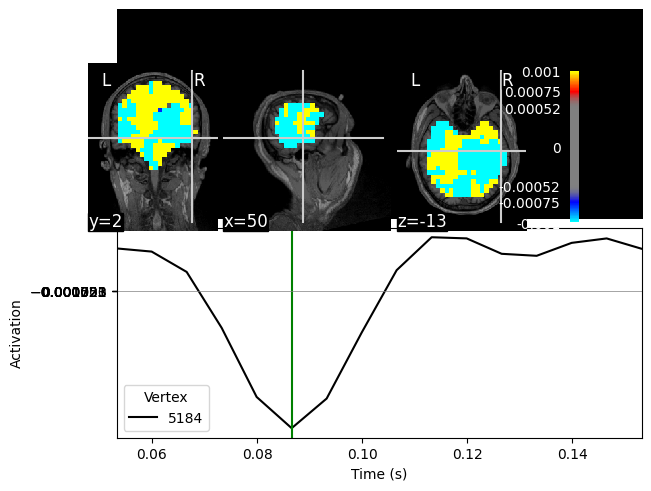

In [12]:
fig=stc.plot(mode='stat_map', clim=dict(kind='percent', pos_lims=lims), **kwargs)

Transforming subject RAS (non-zero origin) -> MNI Talairach
    1.022485 -0.008449 -0.036217       5.60 mm
    0.071071 0.914866 0.406098     -19.82 mm
    0.008756 -0.433700 1.028119      -1.55 mm
    0.000000 0.000000 0.000000       1.00

Fixing initial time: 0.087 s
Showing: t = 0.087 s, (57.9, -19.7, -15.6) mm, [18, 12, 9] vox, 5184 vertex


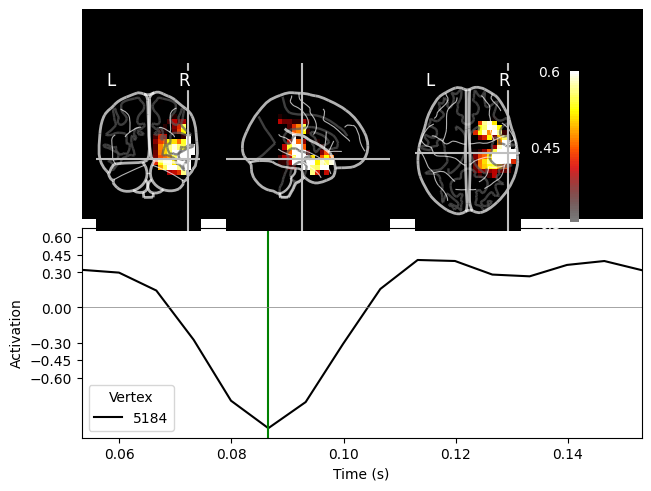

In [13]:
fig=stc.plot(mode='glass_brain', clim=dict(kind='value', lims=lims), **kwargs)

Fixing initial time: 0.087 s
Showing: t = 0.087 s, (50.7, -5.0, 0.7) mm, [18, 11, 11] vox, 6255 vertex


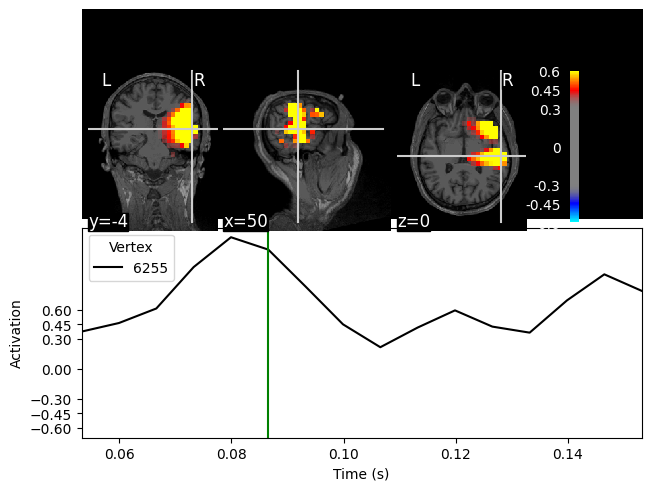

In [14]:
fig=stc_vec.plot(mode='stat_map', clim=dict(kind='value', pos_lims=lims), **kwargs)

Transforming subject RAS (non-zero origin) -> MNI Talairach
    1.022485 -0.008449 -0.036217       5.60 mm
    0.071071 0.914866 0.406098     -19.82 mm
    0.008756 -0.433700 1.028119      -1.55 mm
    0.000000 0.000000 0.000000       1.00

Fixing initial time: 0.087 s
Showing: t = 0.087 s, (57.5, -20.5, 1.8) mm, [18, 11, 11] vox, 6255 vertex


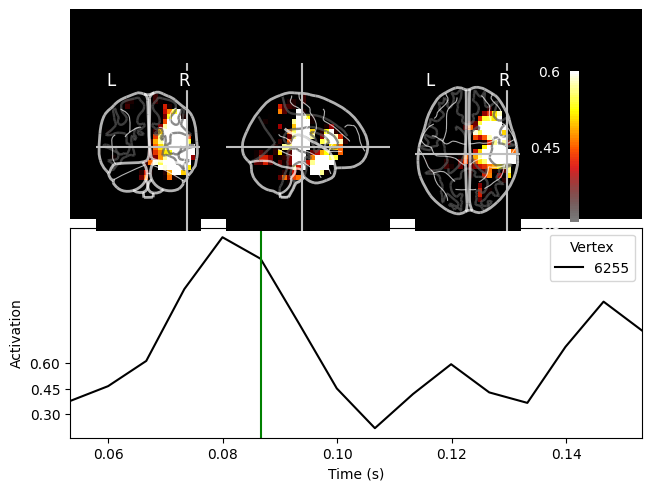

In [15]:
fig=stc_vec.plot(mode='glass_brain', clim=dict(kind='value', lims=lims), **kwargs)

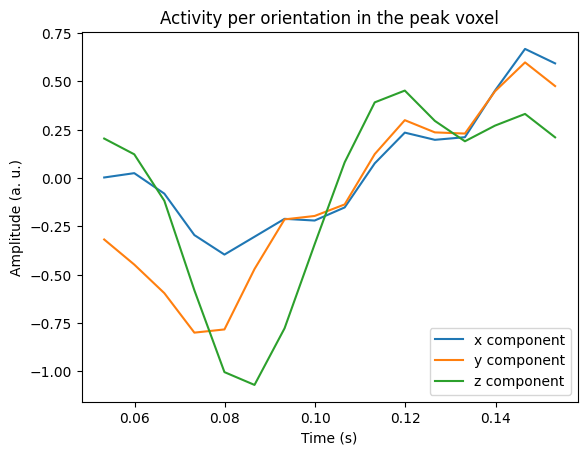

In [16]:
peak_vox, _ = stc_vec.get_peak(tmin=0.08, tmax=0.1, vert_as_index=True)

ori_labels = ['x', 'y', 'z']
fig, ax = plt.subplots(1)
for ori, label in zip(stc_vec.data[peak_vox, :, :], ori_labels):
    ax.plot(stc_vec.times, ori, label='%s component' % label)
ax.legend(loc='lower right')
ax.set(title='Activity per orientation in the peak voxel', xlabel='Time (s)',
       ylabel='Amplitude (a. u.)')
mne.viz.utils.plt_show()
del stc_vec

In [17]:
data_cov.data

array([[ 4.20518663e-23,  8.39517549e-24,  9.68841617e-25, ...,
         1.14948537e-23,  5.80157523e-24,  4.62774103e-25],
       [ 8.39517549e-24,  9.22455074e-24,  3.97153029e-25, ...,
         3.16249006e-24,  5.45988028e-25,  1.61439424e-25],
       [ 9.68841617e-25,  3.97153029e-25,  9.57654596e-26, ...,
        -4.96922890e-27,  1.39554196e-25,  4.33921127e-26],
       ...,
       [ 1.14948537e-23,  3.16249006e-24, -4.96922890e-27, ...,
         5.17437192e-23,  3.38009043e-24, -9.88104744e-26],
       [ 5.80157523e-24,  5.45988028e-25,  1.39554196e-25, ...,
         3.38009043e-24,  3.87060183e-23,  2.01556561e-25],
       [ 4.62774103e-25,  1.61439424e-25,  4.33921127e-26, ...,
        -9.88104744e-26,  2.01556561e-25,  5.24380456e-26]])

In [18]:
data_cov.data.shape

(305, 305)

Computing rank from covariance with rank=None
    Using tolerance 4.2e-14 (2.2e-16 eps * 102 dim * 1.8  max singular value)
    Estimated rank (mag): 102
    MAG: rank 102 computed from 102 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 5.2e-13 (2.2e-16 eps * 203 dim * 12  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors


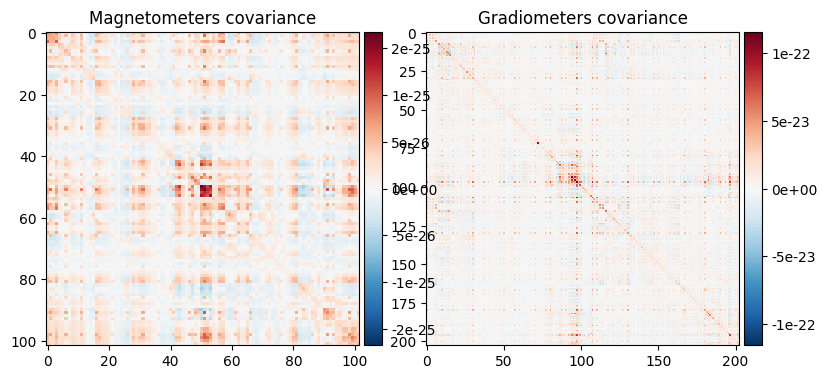

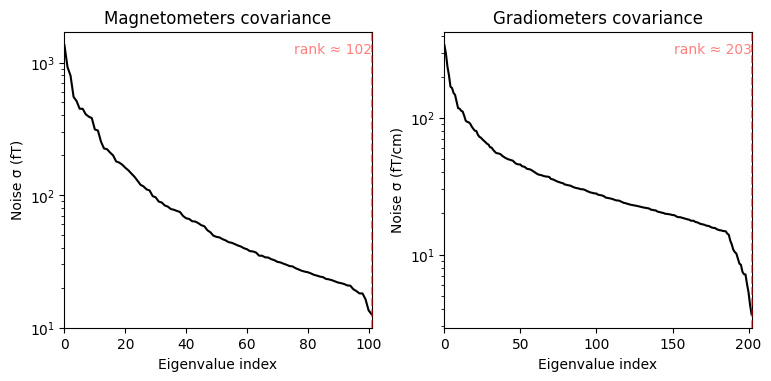

(<Figure size 760x370 with 4 Axes>, <Figure size 760x370 with 2 Axes>)

In [19]:
for i in np.arange(0,305,5):
    for j in np.arange(0,305,5):
        if i!=j:
            data_cov.data[i,j]=0.9*np.sqrt(data_cov.data[i,i]*data_cov.data[j,j])
data_cov.plot(epochs.info)
        

Computing rank from covariance with rank=None
    Using tolerance 8.6e-13 (2.2e-16 eps * 305 dim * 13  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
Computing rank from covariance with rank=None
    Using tolerance 2.9e-13 (2.2e-16 eps * 305 dim * 4.3  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
Making LCMV beamformer with rank {'meg': 302}
Computing inverse operator with 305 channels.
    305 out of 306 channels remain after picking
Selected 305 channels
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 3)
Computing rank from covariance with rank={'meg': 302}
    Setting small MEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 3757 sources


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/beamformer/_compute_beamformer.py:243: RuntimeWarning: divide by zero encountered in matmul
  Cm = whitener @ Cm @ whitener.T.conj()
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/beamformer/_compute_beamformer.py:243: RuntimeWarning: overflow encountered in matmul
  Cm = whitener @ Cm @ whitener.T.conj()
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/beamformer/_compute_beamformer.py:243: RuntimeWarning: invalid value encountered in matmul
  Cm = whitener @ Cm @ whitener.T.conj()
/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58662/847478201.py:1: RuntimeWarning: data covariance does not appear to be positive semidefinite, results will likely be incorrect
  filters = make_lcmv(evoked.info, forward, data_cov, reg=0.05,
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/utils/numerics.py:191: RuntimeWarning: divide by zero encountered in matmul
  x_inv = np.matmul(U * s

Filter computation complete
Fixing initial time: 0.087 s
Showing: t = 0.087 s, (43.7, -12.0, 7.7) mm, [17, 10, 12] vox, 6779 vertex
Using control points [0.45805359 0.5292882  1.1721996 ]


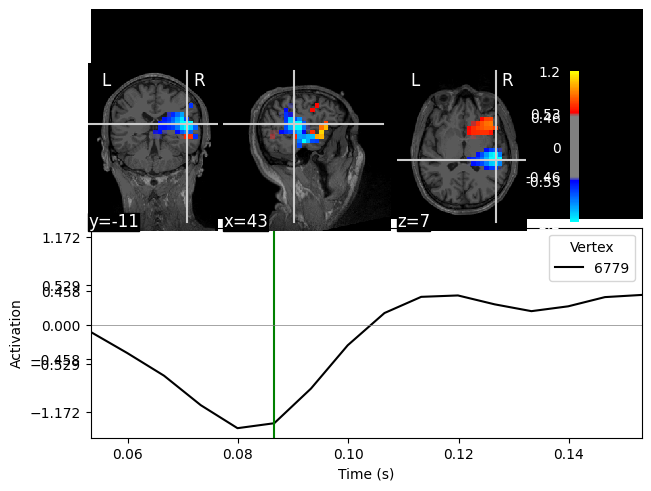

In [20]:
filters = make_lcmv(evoked.info, forward, data_cov, reg=0.05,
                    noise_cov=noise_cov, pick_ori='max-power',
                    weight_norm='unit-noise-gain', rank=None)
stc = apply_lcmv(evoked, filters)
stc_vec = apply_lcmv(evoked, filters_vec)

lims = [0.3, 0.45, 0.6]
kwargs = dict(src=src, subject='sample', subjects_dir=subjects_dir,
              initial_time=0.087, verbose=True)
fig=stc.plot(mode='stat_map', **kwargs)

Computing rank from covariance with rank=None
    Using tolerance 3.8e-15 (2.2e-16 eps * 102 dim * 0.17  max singular value)
    Estimated rank (mag): 102
    MAG: rank 102 computed from 102 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 5.2e-14 (2.2e-16 eps * 203 dim * 1.2  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors


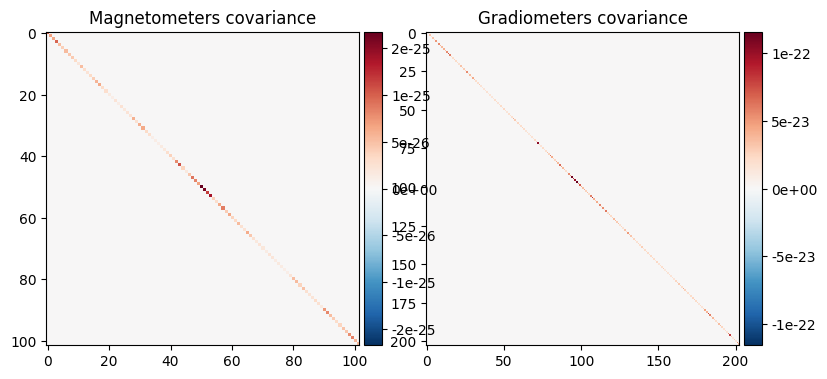

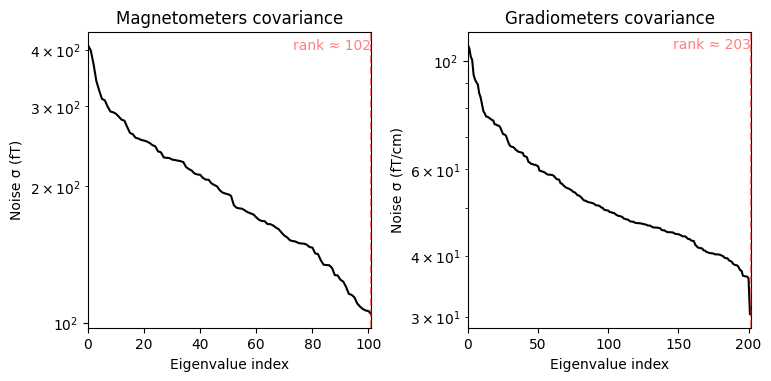

(<Figure size 760x370 with 4 Axes>, <Figure size 760x370 with 2 Axes>)

In [21]:
for i in range(305):
    for j in range(305):
        if i!=j:
            data_cov.data[i,j]=0*np.sqrt(data_cov.data[i,i]*data_cov.data[j,j])
data_cov.plot(epochs.info)
        

Computing rank from covariance with rank=None
    Using tolerance 7.8e-14 (2.2e-16 eps * 305 dim * 1.2  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
Computing rank from covariance with rank=None
    Using tolerance 2.9e-13 (2.2e-16 eps * 305 dim * 4.3  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
Making LCMV beamformer with rank {'meg': 302}
Computing inverse operator with 305 channels.
    305 out of 306 channels remain after picking
Selected 305 channels
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 3)
Computing rank from covariance with rank={'meg': 302}
    Setting small MEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 3757 sources
Filter computation complete


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/beamformer/_compute_beamformer.py:243: RuntimeWarning: divide by zero encountered in matmul
  Cm = whitener @ Cm @ whitener.T.conj()
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/beamformer/_compute_beamformer.py:243: RuntimeWarning: overflow encountered in matmul
  Cm = whitener @ Cm @ whitener.T.conj()
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/beamformer/_compute_beamformer.py:243: RuntimeWarning: invalid value encountered in matmul
  Cm = whitener @ Cm @ whitener.T.conj()
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/utils/numerics.py:191: RuntimeWarning: divide by zero encountered in matmul
  x_inv = np.matmul(U * s_inv[..., np.newaxis, :], Vh)
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/utils/numerics.py:191: RuntimeWarning: overflow encountered in matmul
  x_inv = np.matmul(U * s_inv[..., np.newaxis, :], Vh)
/Users/dkleeva/Library/Python/3.9/lib

Fixing initial time: 0.087 s
Showing: t = 0.087 s, (50.7, -19.0, 28.7) mm, [18, 9, 15] vox, 8397 vertex
Using control points [1.65050931 1.87696614 3.09338011]


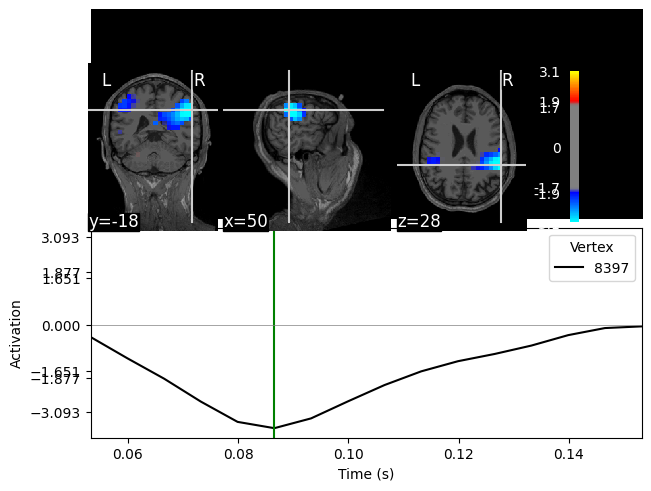

In [22]:
filters = make_lcmv(evoked.info, forward, data_cov, reg=0.05,
                    noise_cov=noise_cov, pick_ori='max-power',
                    weight_norm='unit-noise-gain', rank=None)
stc = apply_lcmv(evoked, filters)
stc_vec = apply_lcmv(evoked, filters_vec)


fig=stc.plot(mode='stat_map', **kwargs)

    Created an SSP operator (subspace dimension = 3)
    Setting small MEG eigenvalues to zero (without PCA)
Reducing data rank from 305 -> 302
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 2035
[done]
    Created an SSP operator (subspace dimension = 3)
    Setting small MEG eigenvalues to zero (without PCA)
Reducing data rank from 305 -> 302
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 1705
[done]
Computing rank from covariance with rank=None
    Using tolerance 4e-14 (2.2e-16 eps * 102 dim * 1.8  max singular value)
    Estimated rank (mag): 99
    MAG: rank 99 computed from 102 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 4.3e-13 (2.2e-16 eps * 203 dim * 9.4  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors


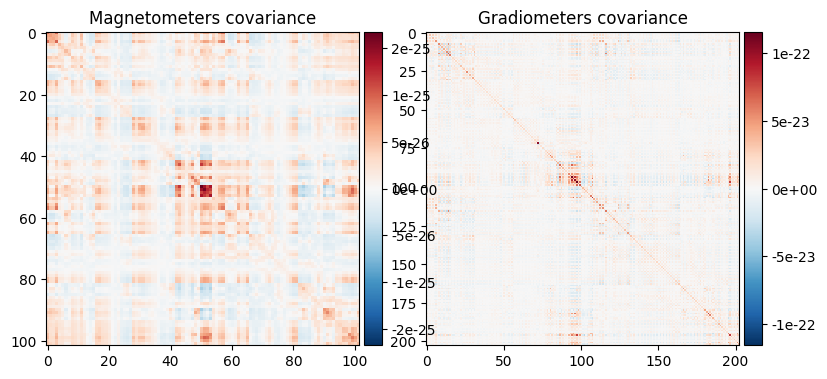

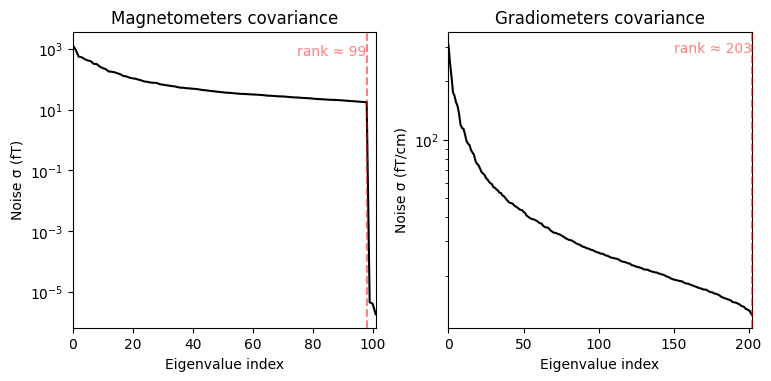

Computing rank from covariance with rank=None
    Using tolerance 1.8e-15 (2.2e-16 eps * 102 dim * 0.08  max singular value)
    Estimated rank (mag): 102
    MAG: rank 102 computed from 102 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 1.9e-14 (2.2e-16 eps * 203 dim * 0.42  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors


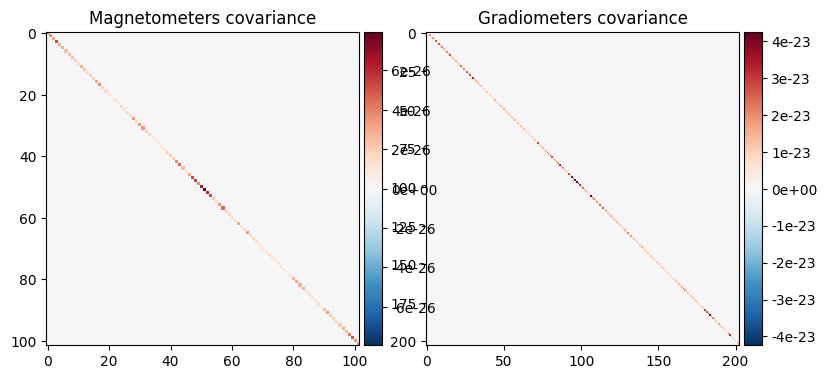

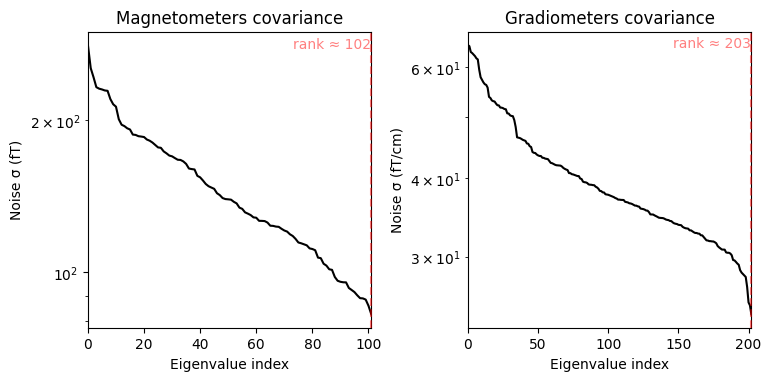

(<Figure size 760x370 with 4 Axes>, <Figure size 760x370 with 2 Axes>)

In [23]:
data_cov = mne.compute_covariance(epochs, tmin=0.01, tmax=0.25,
                                  method='empirical')
noise_cov = mne.compute_covariance(epochs, tmin=tmin, tmax=0,
                                   method='empirical')
for i in range(305):
    for j in range(305):
        if i!=j:
            noise_cov.data[i,j]=0*np.sqrt(noise_cov.data[i,i]*noise_cov.data[j,j])
data_cov.plot(epochs.info)
noise_cov.plot(epochs.info)

Computing rank from covariance with rank=None
    Using tolerance 7.1e-13 (2.2e-16 eps * 305 dim * 10  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
Computing rank from covariance with rank=None
    Using tolerance 2.9e-14 (2.2e-16 eps * 305 dim * 0.42  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
Making LCMV beamformer with rank {'meg': 302}
Computing inverse operator with 305 channels.
    305 out of 306 channels remain after picking
Selected 305 channels
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 3)
Computing rank from covariance with rank={'meg': 302}
    Setting small MEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 3757 sources


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/beamformer/_compute_beamformer.py:243: RuntimeWarning: divide by zero encountered in matmul
  Cm = whitener @ Cm @ whitener.T.conj()
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/beamformer/_compute_beamformer.py:243: RuntimeWarning: overflow encountered in matmul
  Cm = whitener @ Cm @ whitener.T.conj()
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/beamformer/_compute_beamformer.py:243: RuntimeWarning: invalid value encountered in matmul
  Cm = whitener @ Cm @ whitener.T.conj()
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/utils/numerics.py:191: RuntimeWarning: divide by zero encountered in matmul
  x_inv = np.matmul(U * s_inv[..., np.newaxis, :], Vh)
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/utils/numerics.py:191: RuntimeWarning: overflow encountered in matmul
  x_inv = np.matmul(U * s_inv[..., np.newaxis, :], Vh)
/Users/dkleeva/Library/Python/3.9/lib

Filter computation complete
Fixing initial time: 0.087 s
Showing: t = 0.087 s, (50.7, 2.0, -13.3) mm, [18, 12, 9] vox, 5184 vertex
Using control points [0.29423641 0.34395226 0.84229089]


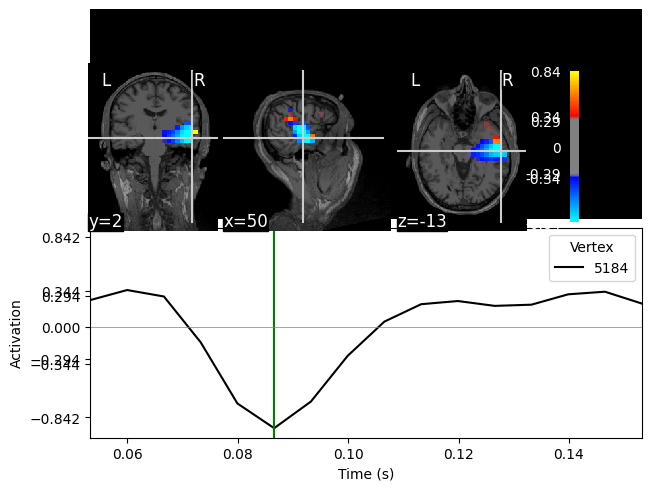

In [24]:
filters = make_lcmv(evoked.info, forward, data_cov, reg=0.05,
                    noise_cov=noise_cov, pick_ori='max-power',
                    weight_norm='unit-noise-gain', rank=None)
stc = apply_lcmv(evoked, filters)
stc_vec = apply_lcmv(evoked, filters_vec)

fig=stc.plot(mode='stat_map', **kwargs)

## Minimum norm estimate

In [ ]:
data_path = sample.data_path()
subjects_dir = str(data_path) + '/subjects'

fname_evoked = str(data_path) + '/MEG/sample/sample_audvis-ave.fif'
evoked = mne.read_evokeds(fname_evoked, condition='Left Auditory',
                          baseline=(None, 0))
fname_fwd = str(data_path) + '/MEG/sample/sample_audvis-meg-eeg-oct-6-fwd.fif'
fname_cov = str(data_path) + '/MEG/sample/sample_audvis-cov.fif'
fwd = mne.read_forward_solution(fname_fwd)
src = fwd['src']
cov = mne.read_cov(fname_cov)

Reading /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis-ave.fif ...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Found the data of interest:
        t =    -199.80 ...     499.49 ms (Left Auditory)
        0 CTF compensation matrices available
        nave = 55 - aspect type = 100
Projections have already been applied. Setting proj attribute to True.
Applying baseline correction (mode: mean)
Reading forward solution from /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis-meg-eeg-oct-6-fwd.fif...
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    2 source spaces read
    Desired named matr

## Regularization

In [26]:
snr = 0.5
lambda2 = 1.0 / snr ** 2
kwargs = dict(initial_time=0.08, hemi='both', subjects_dir=subjects_dir,
              size=(600, 600))

In [27]:
inv = make_inverse_operator(evoked.info, fwd, cov, loose=0., depth=0.8,
                            verbose=True)
stc = stc = abs(apply_inverse(evoked, inv, lambda2, 'MNE', verbose=True))
brain = stc.plot(figure=5, **kwargs)
brain.add_text(0.1, 0.9, 'MNE', 'title', font_size=14)

Computing inverse operator with 364 channels.
    364 out of 366 channels remain after picking
Selected 364 channels
Creating the depth weighting matrix...
    203 planar channels
    limit = 7262/7498 = 10.020866
    scale = 2.58122e-08 exp = 0.8
    Picked elements from a free-orientation depth-weighting prior into the fixed-orientation one
    Average patch normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 4)
Computing rank from covariance with rank=None
    Using tolerance 3.3e-13 (2.2e-16 eps * 305 dim * 4.8  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
    Using tolerance 4.7e-14 (2.2e-16 eps * 59 dim * 3.6  max singular value)
    Estimated rank (eeg): 58
    EEG: rank 58 computed from 59 data channels with 1 projector
    Sett

In [28]:
snr = 10
lambda2 = 1.0 / snr ** 2
kwargs = dict(initial_time=0.08, hemi='both', subjects_dir=subjects_dir,
              size=(600, 600))

In [30]:
inv = make_inverse_operator(evoked.info, fwd, cov, loose=0., depth=0.8,
                            verbose=True)
stc = stc = abs(apply_inverse(evoked, inv, lambda2, 'MNE', verbose=True))
brain = stc.plot(figure=5, **kwargs)
brain.add_text(0.1, 0.9, 'MNE', 'title', font_size=14)

Computing inverse operator with 364 channels.
    364 out of 366 channels remain after picking
Selected 364 channels
Creating the depth weighting matrix...
    203 planar channels
    limit = 7262/7498 = 10.020866
    scale = 2.58122e-08 exp = 0.8
    Picked elements from a free-orientation depth-weighting prior into the fixed-orientation one
    Average patch normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 4)
Computing rank from covariance with rank=None
    Using tolerance 3.3e-13 (2.2e-16 eps * 305 dim * 4.8  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
    Using tolerance 4.7e-14 (2.2e-16 eps * 59 dim * 3.6  max singular value)
    Estimated rank (eeg): 58
    EEG: rank 58 computed from 59 data channels with 1 projector
    Sett

## Impact of normalization

In [31]:
snr = 10
lambda2 = 1.0 / snr ** 2
kwargs = dict(initial_time=0.08, hemi='both', subjects_dir=subjects_dir,
              size=(600, 600))

In [32]:
inv = make_inverse_operator(evoked.info, fwd, cov, loose=0., depth=0.8,
                            verbose=True)
stc = abs(apply_inverse(evoked, inv, lambda2, 'MNE', verbose=True))
brain = stc.plot(figure=5, **kwargs)
brain.add_text(0.1, 0.9, 'MNE', 'title', font_size=14)

Computing inverse operator with 364 channels.
    364 out of 366 channels remain after picking
Selected 364 channels
Creating the depth weighting matrix...
    203 planar channels
    limit = 7262/7498 = 10.020866
    scale = 2.58122e-08 exp = 0.8
    Picked elements from a free-orientation depth-weighting prior into the fixed-orientation one
    Average patch normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 4)
Computing rank from covariance with rank=None
    Using tolerance 3.3e-13 (2.2e-16 eps * 305 dim * 4.8  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
    Using tolerance 4.7e-14 (2.2e-16 eps * 59 dim * 3.6  max singular value)
    Estimated rank (eeg): 58
    EEG: rank 58 computed from 59 data channels with 1 projector
    Sett

/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/pyvistaqt/plotting.py:755: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  self.app_window.setBaseSize(*window_size)


In [33]:
inv = make_inverse_operator(evoked.info, fwd, cov, loose=0., depth=0.8,
                            verbose=True)
stc = abs(apply_inverse(evoked, inv, lambda2, 'dSPM', verbose=True))
brain = stc.plot(figure=5, **kwargs)
brain.add_text(0.1, 0.9, 'MNE', 'title', font_size=14)

Computing inverse operator with 364 channels.
    364 out of 366 channels remain after picking
Selected 364 channels
Creating the depth weighting matrix...
    203 planar channels
    limit = 7262/7498 = 10.020866
    scale = 2.58122e-08 exp = 0.8
    Picked elements from a free-orientation depth-weighting prior into the fixed-orientation one
    Average patch normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 4)
Computing rank from covariance with rank=None
    Using tolerance 3.3e-13 (2.2e-16 eps * 305 dim * 4.8  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
    Using tolerance 4.7e-14 (2.2e-16 eps * 59 dim * 3.6  max singular value)
    Estimated rank (eeg): 58
    EEG: rank 58 computed from 59 data channels with 1 projector
    Sett

/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/pyvistaqt/plotting.py:755: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  self.app_window.setBaseSize(*window_size)


## Using data covariance for inverse modeling

Projections have already been applied. Setting proj attribute to True.


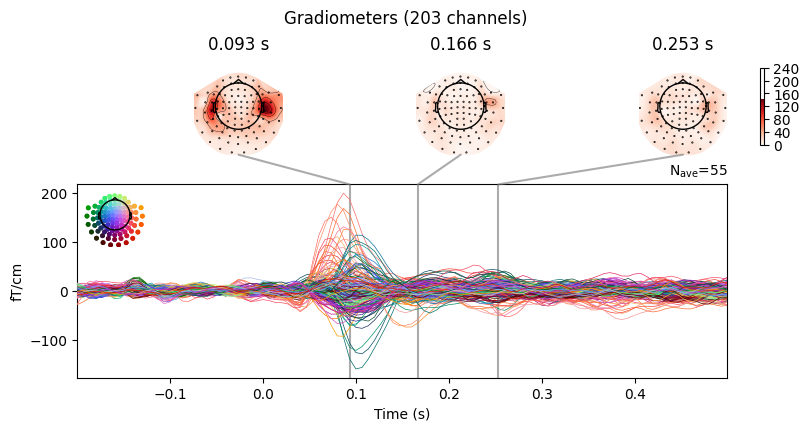

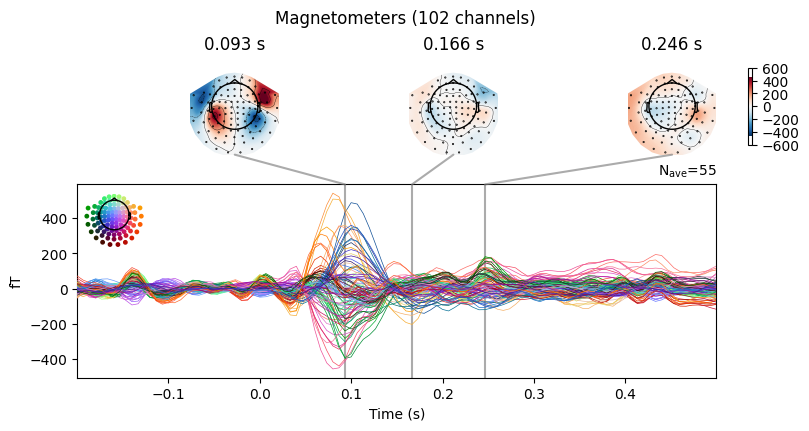

[<Figure size 800x420 with 6 Axes>, <Figure size 800x420 with 6 Axes>]

In [34]:
epochs.average().plot_joint()

In [35]:
noise_cov = mne.make_ad_hoc_cov(epochs.info)
base_cov = mne.compute_covariance(
    epochs, tmin=-0.2, tmax=0, method='shrunk', verbose=True)
data_cov = mne.compute_covariance(
    epochs, tmin=0.07, tmax=0.13, method='shrunk', verbose=True)


    Created an SSP operator (subspace dimension = 3)
    Setting small MEG eigenvalues to zero (without PCA)
Reducing data rank from 305 -> 302
Estimating covariance using SHRUNK


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: divide by zero encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: overflow encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: invalid value encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:2311: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:2311: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/numpy/li

Done.
Number of samples used : 1705
[done]
    Created an SSP operator (subspace dimension = 3)
    Setting small MEG eigenvalues to zero (without PCA)
Reducing data rank from 305 -> 302
Estimating covariance using SHRUNK


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: divide by zero encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: overflow encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: invalid value encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:2311: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:2311: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/numpy/li

Done.
Number of samples used : 550
[done]


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: divide by zero encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: overflow encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: invalid value encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:2311: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:2311: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/numpy/li

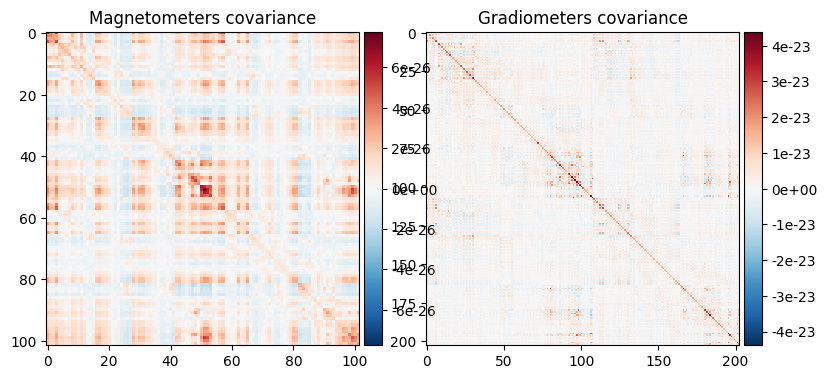

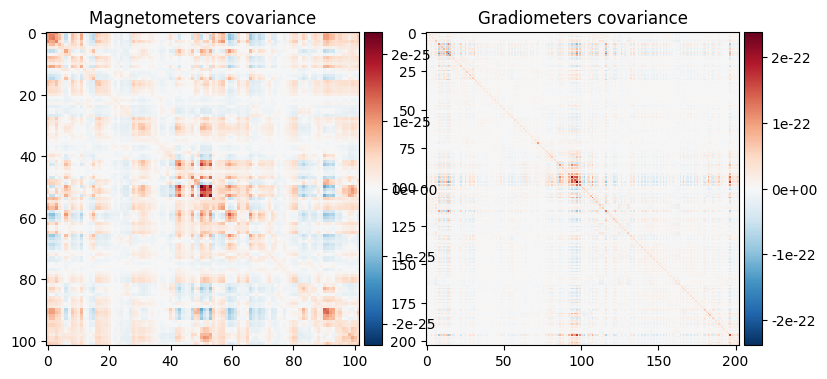

In [36]:

fig_base_cov = mne.viz.plot_cov(base_cov, epochs.info, show_svd=False)
fig_data_cov = mne.viz.plot_cov(data_cov, epochs.info, show_svd=False)

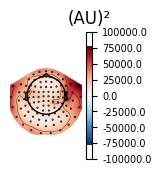

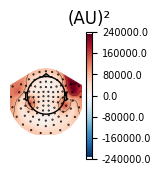

In [37]:
fig = base_cov.plot_topomap(evoked.info)
fig = data_cov.plot_topomap(evoked.info)

In [38]:
inv = make_inverse_operator(epochs.info, fwd, cov, loose=0., depth=0.8,
                            verbose=True)

info["bads"] and noise_cov["bads"] do not match, excluding bad channels from both
Computing inverse operator with 305 channels.
    305 out of 366 channels remain after picking
Selected 305 channels
Creating the depth weighting matrix...
    203 planar channels
    limit = 7262/7498 = 10.020866
    scale = 2.58122e-08 exp = 0.8
    Picked elements from a free-orientation depth-weighting prior into the fixed-orientation one
    Average patch normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 3)
Computing rank from covariance with rank=None
    Using tolerance 3.3e-13 (2.2e-16 eps * 305 dim * 4.8  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
    Setting small MEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adj

In [39]:
stc_data = mne.minimum_norm.apply_inverse_cov(data_cov, evoked.info, inv,
                             nave=len(epochs), method='dSPM', verbose=True)
stc_base = mne.minimum_norm.apply_inverse_cov(base_cov, evoked.info, inv,
                             nave=len(epochs), method='dSPM', verbose=True)

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 55
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 3)
    Created the whitener using a noise covariance matrix with rank 302 (3 small eigenvalues omitted)
    Computing noise-normalization factors (dSPM)...
[done]
Applying inverse operator to "cov"...
    Picked 305 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained  45.5% variance
    dSPM...
[done]
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 55
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 3)
    Created the whitener using a noise covariance matrix with rank 302 (3 small eigenvalues omitted)
    Computing noise-normalization factors (dSPM)...
[done]
Applying inverse operator to "cov"...
    Picked 305 channels from th

/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/minimum_norm/inverse.py:1682: RuntimeWarning: divide by zero encountered in matmul
  sol = cov.data[sel][:, sel] @ K.T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/minimum_norm/inverse.py:1682: RuntimeWarning: overflow encountered in matmul
  sol = cov.data[sel][:, sel] @ K.T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/minimum_norm/inverse.py:1682: RuntimeWarning: invalid value encountered in matmul
  sol = cov.data[sel][:, sel] @ K.T


In [40]:
brain = stc_base.plot(figure=5, **kwargs)

Using control points [109.56747457 111.32267023 121.22065154]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


In [41]:
brain = stc_data.plot(figure=5, **kwargs)

Using control points [297.71720029 312.54291758 608.18527706]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


In [42]:
stc_data /= stc_base
brain = stc_data.plot(figure=5, **kwargs)

Using control points [3.05275293 3.26327061 6.94063916]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


## Source leakage

In [43]:
from mne.minimum_norm import (read_inverse_operator,
                              make_inverse_resolution_matrix,
                              get_point_spread)

In [44]:
fname_fwd = str(data_path) + '/MEG/sample/sample_audvis-meg-eeg-oct-6-fwd.fif'
fname_inv = str(data_path) + '/MEG/sample/sample_audvis-meg-oct-6-meg-fixed-inv.fif'
forward = mne.read_forward_solution(fname_fwd)
mne.convert_forward_solution(
    forward, surf_ori=True, force_fixed=True, copy=False)
inv = read_inverse_operator(fname_inv)

Reading forward solution from /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis-meg-eeg-oct-6-fwd.fif...
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    2 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (7498 sources, 306 channels, free orientations)
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read EEG forward solution (7498 sources, 60 channels, free orientations)
    Forward solutions combined: MEG, EEG
    Source spaces transformed to the forward solution coordinate frame
    Average patch normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source o

In [45]:
labels = mne.read_labels_from_annot('sample', parc='aparc',
                                    subjects_dir=subjects_dir)


Reading labels from parcellation...
   read 34 labels from /Users/dkleeva/mne_data/MNE-sample-data/subjects/sample/label/lh.aparc.annot
   read 34 labels from /Users/dkleeva/mne_data/MNE-sample-data/subjects/sample/label/rh.aparc.annot


In [46]:
labels

[<Label | sample, 'bankssts-lh', lh : 1604 vertices>,
 <Label | sample, 'bankssts-rh', rh : 1555 vertices>,
 <Label | sample, 'caudalanteriorcingulate-lh', lh : 1277 vertices>,
 <Label | sample, 'caudalanteriorcingulate-rh', rh : 1982 vertices>,
 <Label | sample, 'caudalmiddlefrontal-lh', lh : 3810 vertices>,
 <Label | sample, 'caudalmiddlefrontal-rh', rh : 3994 vertices>,
 <Label | sample, 'cuneus-lh', lh : 2545 vertices>,
 <Label | sample, 'cuneus-rh', rh : 2479 vertices>,
 <Label | sample, 'entorhinal-lh', lh : 726 vertices>,
 <Label | sample, 'entorhinal-rh', rh : 571 vertices>,
 <Label | sample, 'frontalpole-lh', lh : 350 vertices>,
 <Label | sample, 'frontalpole-rh', rh : 483 vertices>,
 <Label | sample, 'fusiform-lh', lh : 5209 vertices>,
 <Label | sample, 'fusiform-rh', rh : 4843 vertices>,
 <Label | sample, 'inferiorparietal-lh', lh : 7839 vertices>,
 <Label | sample, 'inferiorparietal-rh', rh : 8562 vertices>,
 <Label | sample, 'inferiortemporal-lh', lh : 6363 vertices>,
 <La

In [47]:
label_colors = [label.color for label in labels]
label_names = [label.name for label in labels]
lh_labels = [name for name in label_names if name.endswith('lh')]

label_ypos = list()
for name in lh_labels:
    idx = label_names.index(name)
    ypos = np.mean(labels[idx].pos[:, 1])
    label_ypos.append(ypos)

lh_labels = [label for (yp, label) in sorted(zip(label_ypos, lh_labels))]

rh_labels = [label[:-2] + 'rh' for label in lh_labels]

In [48]:
rm_mne = make_inverse_resolution_matrix(forward, inv,
                                        method='MNE', lambda2=1. / 3.**2)

    305 out of 366 channels remain after picking
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 1
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 3)
    Created the whitener using a noise covariance matrix with rank 302 (3 small eigenvalues omitted)
Applying inverse operator to ""...
    Picked 305 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained  44.6% variance
[done]
Dimension of Inverse Matrix: (7498, 305)
Dimensions of resolution matrix: 7498 by 7498.


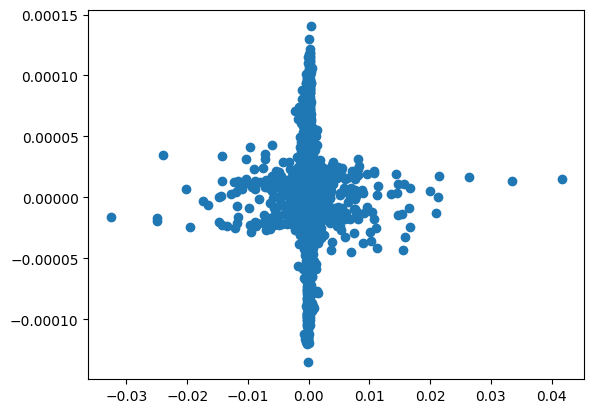

In [49]:
plt.scatter(rm_mne[0,:], forward['sol']['data'][0,:])

In [50]:
rm_mne.shape

(7498, 7498)

In [51]:


n_comp = 5
stcs_psf_mne, pca_vars_mne = get_point_spread(
    rm_mne, src, labels, mode="pca", n_comp=n_comp, norm=None, return_pca_vars=True
)
n_verts = rm_mne.shape[0]
del rm_mne

In [52]:
stcs_psf_mne

[<SourceEstimate | 7498 vertices, subject : sample, tmin : 0.0 (ms), tmax : 4000.0 (ms), tstep : 1000.0 (ms), data shape : (7498, 5), ~352 kB>,
 <SourceEstimate | 7498 vertices, subject : sample, tmin : 0.0 (ms), tmax : 4000.0 (ms), tstep : 1000.0 (ms), data shape : (7498, 5), ~352 kB>,
 <SourceEstimate | 7498 vertices, subject : sample, tmin : 0.0 (ms), tmax : 4000.0 (ms), tstep : 1000.0 (ms), data shape : (7498, 5), ~352 kB>,
 <SourceEstimate | 7498 vertices, subject : sample, tmin : 0.0 (ms), tmax : 4000.0 (ms), tstep : 1000.0 (ms), data shape : (7498, 5), ~352 kB>,
 <SourceEstimate | 7498 vertices, subject : sample, tmin : 0.0 (ms), tmax : 4000.0 (ms), tstep : 1000.0 (ms), data shape : (7498, 5), ~352 kB>,
 <SourceEstimate | 7498 vertices, subject : sample, tmin : 0.0 (ms), tmax : 4000.0 (ms), tstep : 1000.0 (ms), data shape : (7498, 5), ~352 kB>,
 <SourceEstimate | 7498 vertices, subject : sample, tmin : 0.0 (ms), tmax : 4000.0 (ms), tstep : 1000.0 (ms), data shape : (7498, 5), ~3

In [53]:
len(stcs_psf_mne)

68

In [54]:
idx=0
labels[idx]

<Label | sample, 'bankssts-lh', lh : 1604 vertices>

In [55]:
stcs_psf_mne[idx].plot(figure=5, subject='sample', subjects_dir= subjects_dir, hemi='both')

Using control points [0.02706929 0.03513679 0.11096394]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/pyvistaqt/plotting.py:755: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  self.app_window.setBaseSize(*window_size)


In [56]:
with np.printoptions(precision=1):
    for [name, var] in zip(label_names, pca_vars_mne):
        print(f'{name}: {var.sum():.1f}% {var}')

bankssts-lh: 94.1% [41.1 33.4 10.8  5.4  3.5]
bankssts-rh: 94.7% [56.7 15.8 14.3  4.5  3.4]
caudalanteriorcingulate-lh: 97.9% [72.7 14.8  5.2  3.5  1.7]
caudalanteriorcingulate-rh: 96.8% [63.4 18.7  9.3  3.   2.4]
caudalmiddlefrontal-lh: 91.8% [35.7 25.5 14.9  8.2  7.4]
caudalmiddlefrontal-rh: 90.3% [30.2 27.5 15.9  9.3  7.3]
cuneus-lh: 95.1% [40.6 28.9 17.1  5.7  2.8]
cuneus-rh: 94.4% [39.1 32.5 15.8  3.8  3.3]
entorhinal-lh: 98.6% [52.6 27.5 10.2  6.3  2.1]
entorhinal-rh: 99.6% [48.8 37.1 12.2  0.9  0.6]
frontalpole-lh: 99.9% [70.  22.8  3.5  3.1  0.5]
frontalpole-rh: 99.8% [69.1 24.8  3.3  2.1  0.6]
fusiform-lh: 89.4% [37.9 23.  16.4  6.7  5.4]
fusiform-rh: 88.8% [32.1 28.5 15.6  6.9  5.7]
inferiorparietal-lh: 79.8% [24.1 19.1 16.9 11.2  8.5]
inferiorparietal-rh: 79.5% [24.5 17.6 16.  11.8  9.7]
inferiortemporal-lh: 85.2% [27.  22.9 15.8 11.9  7.8]
inferiortemporal-rh: 87.4% [31.8 23.2 16.3  8.4  7.7]
insula-lh: 89.9% [34.7 29.1 12.4  9.6  4. ]
insula-rh: 91.8% [39.9 26.  11.9 10.5 

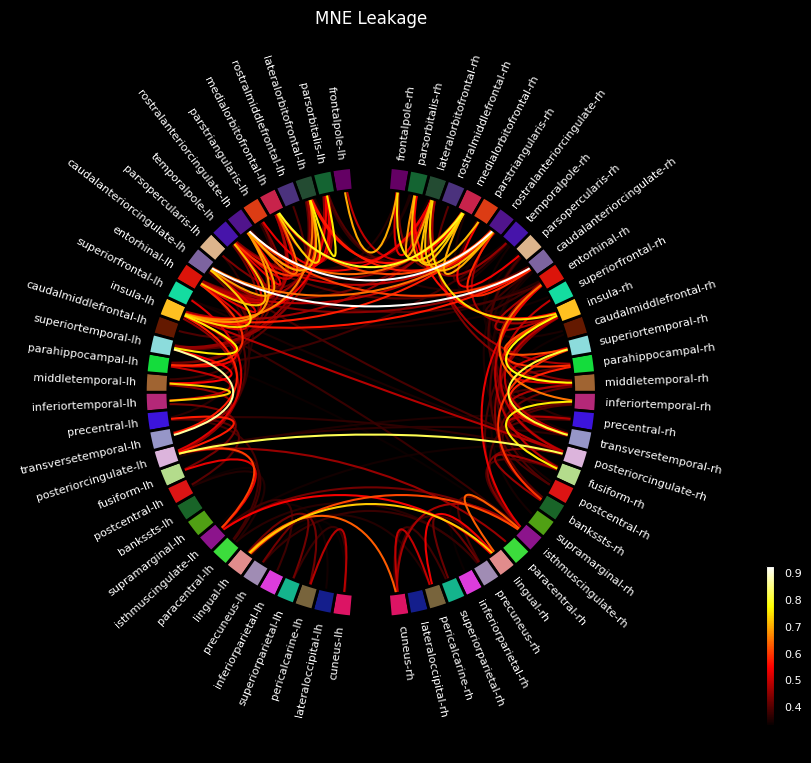

(<Figure size 800x800 with 2 Axes>,
 <PolarAxes: title={'center': 'MNE Leakage'}>)

In [57]:
n_labels=len(labels)

psfs_mat = np.zeros([n_labels, n_verts])

for [i, s] in enumerate(stcs_psf_mne):
    psfs_mat[i, :] = s.data[:, 0]

leakage_mne = np.abs(np.corrcoef(psfs_mat))


node_order = lh_labels[::-1] + rh_labels  
node_angles = circular_layout(label_names, node_order, start_pos=90,
                              group_boundaries=[0, len(label_names) / 2])


plot_connectivity_circle(leakage_mne, label_names, n_lines=200,
                         node_angles=node_angles, node_colors=label_colors,
                         title='MNE Leakage')

## Other inverse operators?

In [58]:
inv = make_inverse_operator(evoked.info, fwd, noise_cov, loose=0., depth=0.8,
                            verbose=True)

info["bads"] and noise_cov["bads"] do not match, excluding bad channels from both
Computing inverse operator with 305 channels.
    305 out of 366 channels remain after picking
Selected 305 channels
Creating the depth weighting matrix...
    203 planar channels
    limit = 7262/7498 = 10.020866
    scale = 2.58122e-08 exp = 0.8
    Picked elements from a free-orientation depth-weighting prior into the fixed-orientation one
    Average patch normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 3)
Computing rank from covariance with rank=None
    Using tolerance 1.7e-16 (2.2e-16 eps * 305 dim * 0.0025  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
    Setting small MEG eigenvalues to zero (without PCA)
Creating the source covariance matrix


In [59]:
snr = 3.0
lambda2 = 1.0 / snr ** 2
kwargs = dict(initial_time=0.08, hemi='both', subjects_dir=subjects_dir,
              size=(600, 600))
stc = abs(apply_inverse(evoked, inv, lambda2, 'MNE', verbose=True))
brain = stc.plot(figure=1, **kwargs)
brain.add_text(0.1, 0.9, 'MNE', 'title', font_size=14)

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 55
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 3)
    Created the whitener using a noise covariance matrix with rank 302 (3 small eigenvalues omitted)
Applying inverse operator to "Left Auditory"...
    Picked 305 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained  94.2% variance
[done]
Using control points [9.62607492e-11 1.17303147e-10 3.48213263e-10]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can insta

In [60]:
snr = 3.0
lambda2 = 1.0 / snr ** 2
kwargs = dict(initial_time=0.08, hemi='both', subjects_dir=subjects_dir,
              size=(600, 600))
stc = abs(apply_inverse(evoked, inv, lambda2, 'dSPM', verbose=True))
brain = stc.plot(figure=1, **kwargs)
brain.add_text(0.1, 0.9, 'dSPM', 'title', font_size=14)

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 55
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 3)
    Created the whitener using a noise covariance matrix with rank 302 (3 small eigenvalues omitted)
    Computing noise-normalization factors (dSPM)...
[done]
Applying inverse operator to "Left Auditory"...
    Picked 305 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained  94.2% variance
    dSPM...
[done]
Using control points [ 43.65727261  52.04522564 213.15966837]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic

/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/pyvistaqt/plotting.py:755: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  self.app_window.setBaseSize(*window_size)


In [61]:
snr = 3.0
lambda2 = 1.0 / snr ** 2
kwargs = dict(initial_time=0.08, hemi='both', subjects_dir=subjects_dir,
              size=(600, 600))
stc = abs(apply_inverse(evoked, inv, lambda2, 'eLORETA', verbose=True))
brain = stc.plot(figure=1, **kwargs)
brain.add_text(0.1, 0.9, 'eLORETA', 'title', font_size=14)

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 55
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 3)
    Created the whitener using a noise covariance matrix with rank 302 (3 small eigenvalues omitted)
    Computing optimized source covariance (eLORETA)...
        Fitting up to 20 iterations...
        Converged on iteration 10 (6.8e-07 < 1e-06)
        Updating inverse with weighted eigen leads


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/minimum_norm/_eloreta.py:169: RuntimeWarning: divide by zero encountered in matmul
  G_R_Gt = G @ R_Gt
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/minimum_norm/_eloreta.py:169: RuntimeWarning: overflow encountered in matmul
  G_R_Gt = G @ R_Gt
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/minimum_norm/_eloreta.py:169: RuntimeWarning: invalid value encountered in matmul
  G_R_Gt = G @ R_Gt


[done]
Applying inverse operator to "Left Auditory"...
    Picked 305 channels from the data
    Computing inverse...
    Eigenleads already weighted ... 
    Computing residual...
    Explained  94.0% variance
[done]
Using control points [8.95865490e-11 1.06525416e-10 3.17715583e-10]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/pyvistaqt/plotting.py:755: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  self.app_window.setBaseSize(*window_size)
